# MergeSite detectors — one visual exemplar of each topology

`candidate_merge_sites` uses THREE detectors because a merge error (one segment id covering
two real neurons) shows up as three DIFFERENT skeleton topologies — and each detector is the
only one that can see its shape:

  * **branch**    — the two neurites meet at a degree>=3 node (a touch / crossing).
  * **bridge**    — they fuse end-to-end through a thin degree-2 NECK with a sharp kink
                    (NO branch node — the branch scan structurally misses it).
  * **component** — one label spans >=2 DISCONNECTED graph pieces (no shared vertex at all —
                    walk-based detectors can't reach across).

This notebook picks ONE clear exemplar per detector from a real brain and renders it: the raw
image MIP + the fragment skeleton (coloured by connected component) with the cut node and the
two seeds marked, so the three shapes are concrete side by side. Uses the same `img_util` /
`*_add.pkl` viz cache the policy-comparison notebook uses. Big-memory node, `panda` env.

## 0. Setup — enumerate MergeSites, load the viz cache

In [1]:
import sys, json
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt

PROJ = Path("../..").resolve()
sys.path.insert(0, str(PROJ))
sys.path.insert(0, str(PROJ.parent / "segmentation-skeleton-metrics" / "src"))
from proofreader_evolve.harness import dataset as ds
from agentic_neuron_proofreader.utils import img_util
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset

# --- params -------------------------------------------------------------------
BRAIN = "794495"
MCL   = 100
PATCH = 160                       # receptive-field cube side (voxels) for each example
WITH_IMAGE = True                 # also render the raw fluorescence MIP (needs GCS reader)
MERGE = dict(min_arm_cable_um=10.0, seed_depth_um=8.0, max_sites=5000, max_per_label=4)

# Load the fragment graph, then enumerate MergeSites (uses the persistent cache if
# present, else ~tens of min; set n_workers>1 to parallelize — result is identical).
# Every site carries .detector.
print("Start loading")
frag, _gt, _ = ds.load_cached_graphs(
    ds.default_cache_path(BRAIN, min_cable_length=MCL), expect_brain=BRAIN, expect_mcl=MCL)
sites = ds.candidate_merge_sites(frag, **MERGE, n_workers=4)
by_det = {}
for s in sites:
    by_det.setdefault(s.detector, []).append(s)
print(f"{len(sites)} MergeSites: " + ", ".join(f"{d}={len(v)}" for d, v in sorted(by_det.items())))

# Viz cache (*_add.pkl): agentic SkeletonGraph with nodes_in_patch + GCS image reader.
bd = BrainDataset.load_from_cache(f"../../cache/dataset_cache_{BRAIN}_mcl{MCL}_add.pkl")
fr_viz = bd.fragments_graph
aniso = fr_viz.anisotropy
PATCH_SHAPE = (PATCH, PATCH, PATCH)

Start loading
[candidate_merge_sites] PARALLEL: 4 worker(s) over 20,876,161 nodes (5,219,041 nodes/block); this process is pinned to 4 CPU(s).
[candidate_merge_sites] PARALLEL: 4 worker(s) finished in 1111.8s.
5000 MergeSites: branch=3802, bridge=1187, component=11


## 1. Pick one clear exemplar per detector

For each detector, choose the site with the LONGEST min-arm cable (the most unambiguous
example — both neurites are long and real). `component` sites have `branch_degree=0`;
`bridge` are degree-2 necks; `branch` are degree>=3.

**`NEAR_GT`** (new): when True, `pick(det, near_gt=True)` returns the strongest site *whose
patch contains ≥1 GROUND-TRUTH skeleton node*, so §2b's GT panel is populated instead of
landing in an untraced region (the default top-by-cable picks fell in GT-empty areas). It
scans candidates strongest-first and takes the first GT-covered one; if a detector has NO
GT-covered site it falls back to the overall strongest and prints a note. The printout adds
`GT_nodes_in_patch=` so you can see the GT coverage of each chosen exemplar.

In [56]:
import random

# --- selection knobs ----------------------------------------------------------
NEAR_GT  = True    # require the patch to contain GROUND-TRUTH skeleton
MIN_GT_NEURONS = 2 # how many DISTINCT GT neurons (components) must be in the patch.
                   # 2 => the patch shows TWO GT neurons meeting (a real merge picture);
                   # 1 => any GT present; ignored when NEAR_GT is False.
RANDOM   = True    # True: pick a RANDOM eligible site each run; False: strongest by cable
SEED     = None    # None -> DIFFERENT pick every run (system entropy); int -> reproducible

_gt_pick = bd.gt_graph      # GT viz for the near_gt test (same *_add cache)
_rng = random.Random(SEED)  # SEED=None => reseeded from entropy each run => fresh picks

def _patch_gt_stats(s):
    """(# GT nodes, # DISTINCT GT neurons) inside this site's PATCH_SHAPE window.
    'GT neurons' = distinct GT connected-component ids among the patch's GT nodes."""
    center_voxel = img_util.to_voxels(tuple(s.cut_xyz), aniso)          # (z, y, x)
    offset = tuple(c - d // 2 for c, d in zip(center_voxel, PATCH_SHAPE))
    gt_nodes, gt_ncomp = _gt_pick.nodes_in_patch(offset, PATCH_SHAPE, return_components=True)
    n_neurons = len(set(gt_ncomp)) if len(gt_ncomp) else 0
    return len(gt_nodes), n_neurons

def pick(det, near_gt=False, random_pick=False, min_gt_neurons=1):
    """One exemplar for a detector, or None if none enumerated.

    ``random_pick=True``: shuffle this detector's sites (via ``_rng``) and take the
    first — a uniformly RANDOM site, different each run when ``SEED`` is None. Otherwise
    strongest by min-arm cable (deterministic). ``near_gt=True``: skip to the first site
    (in the chosen order) whose patch contains >= ``min_gt_neurons`` DISTINCT GT neurons —
    so ``min_gt_neurons=2`` yields a patch showing two GT neurons meeting (the visual of a
    real merge). Falls back to the first site if none qualify (prints a note)."""
    cand = by_det.get(det, [])
    if not cand:
        return None
    if random_pick:
        order = list(cand); _rng.shuffle(order)     # random order => random pick
    else:
        order = sorted(cand, key=lambda s: min(s.cable_a_um, s.cable_b_um), reverse=True)
    if not near_gt:
        return order[0]
    for s in order:                                 # first patch with >= min_gt_neurons GT neurons
        if _patch_gt_stats(s)[1] >= min_gt_neurons:
            return s
    print(f"    [{det}] no site with >= {min_gt_neurons} GT neuron(s) in patch — "
          f"falling back to first in order")
    return order[0]

examples = {det: pick(det, near_gt=NEAR_GT, random_pick=RANDOM,
                       min_gt_neurons=MIN_GT_NEURONS)
            for det in ("branch", "bridge", "component")}
print(f"selection: {'RANDOM' if RANDOM else 'strongest-by-cable'}"
      f"{' (seed=%d)' % SEED if SEED is not None else ' (fresh each run)'}"
      f"{f', require >={MIN_GT_NEURONS} GT neuron(s) in patch' if NEAR_GT else ''}")
for det, s in examples.items():
    if s is None:
        print(f"{det:10}: (none enumerated)")
    else:
        _ngt, _nneu = _patch_gt_stats(s)
        print(f"{det:10}: label {s.label}  cut_node {s.cut_node}  deg {s.branch_degree}  "
              f"cables {s.cable_a_um:.1f}/{s.cable_b_um:.1f}um  angle {s.angle_deg:.0f}  "
              f"GT_nodes={_ngt} GT_neurons={_nneu}  @ {tuple(round(v,1) for v in s.cut_xyz)}um")

    [component] no site with >= 2 GT neuron(s) in patch — falling back to first in order
selection: RANDOM (fresh each run), require >=2 GT neuron(s) in patch
branch    : label 26541564599  cut_node 12334641  deg 3  cables 28.5/28.3um  angle 146  GT_nodes=146 GT_neurons=2  @ (29316.0, 17881.0, 13715.0)um
bridge    : label 20215376686  cut_node 11101971  deg 2  cables 28.5/29.2um  angle 115  GT_nodes=67 GT_neurons=2  @ (40447.7, 15302.6, 10099.3)um
component : label 27735706173  cut_node 14863714  deg 0  cables 209.7/158.8um  angle nan  GT_nodes=0 GT_neurons=0  @ (35564.0, 25289.5, 13428.5)um


## 2. Render each exemplar

Raw image MIP (if enabled) + the fragment skeleton coloured by connected component within
the patch, with the CUT node (yellow X) and the two SEEDS (cyan/magenta dots) marked. The
cut is where a `split_label` would separate the two fused neurites.


=== [branch] label 26541564599  deg 3  cables 28.5/28.3um  angle 146deg ===
    two neurites meet at a degree>=3 node (touch / crossing)
    fragment nodes/edges in patch: 125/122
Raw image (MIP):


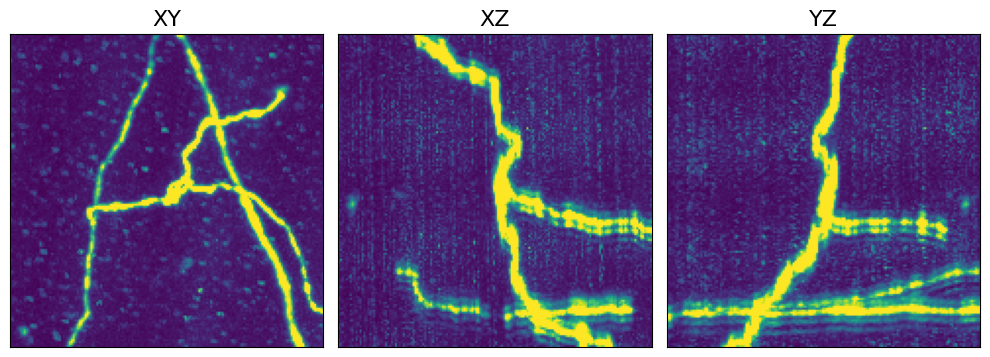

[branch] Fragment skeleton (coloured by connected component):


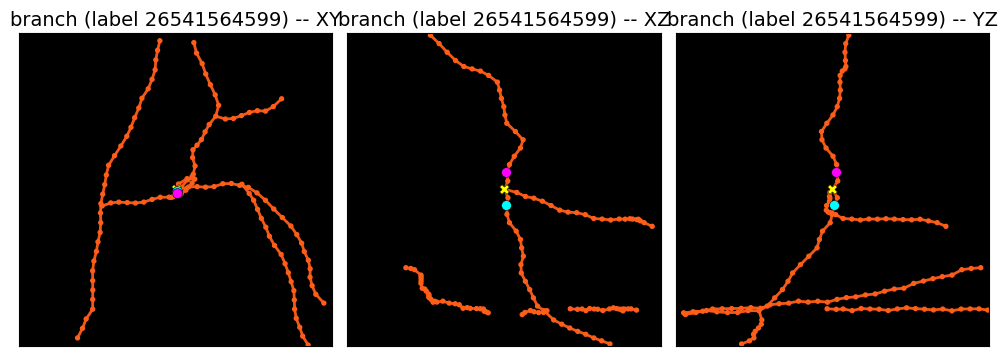


=== [bridge] label 20215376686  deg 2  cables 28.5/29.2um  angle 115deg ===
    two neurites fused end-to-end at a degree-2 NECK with a sharp kink (no branch node — branch scan misses it)
    fragment nodes/edges in patch: 101/97
Raw image (MIP):


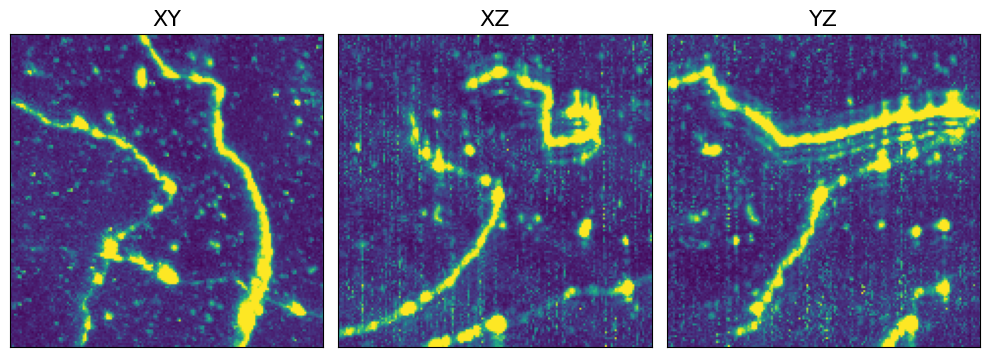

[bridge] Fragment skeleton (coloured by connected component):


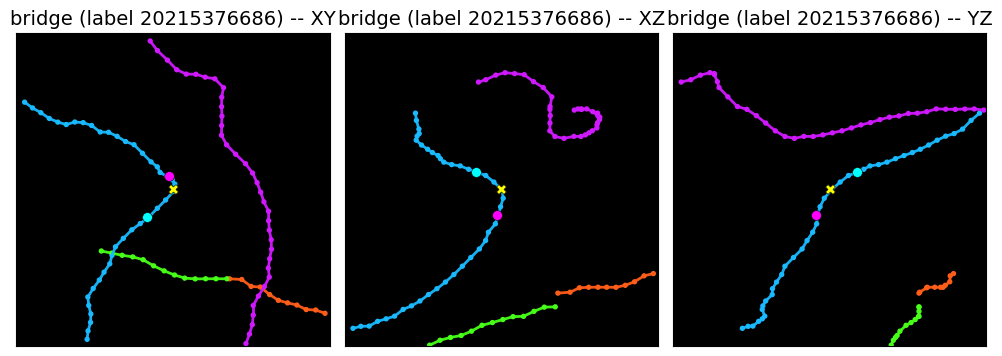


=== [component] label 27735706173  deg 0  cables 209.7/158.8um  angle nandeg ===
    one label over >=2 DISCONNECTED components (no shared vertex — walk-based detectors can't reach across)
    fragment nodes/edges in patch: 272/255
Raw image (MIP):


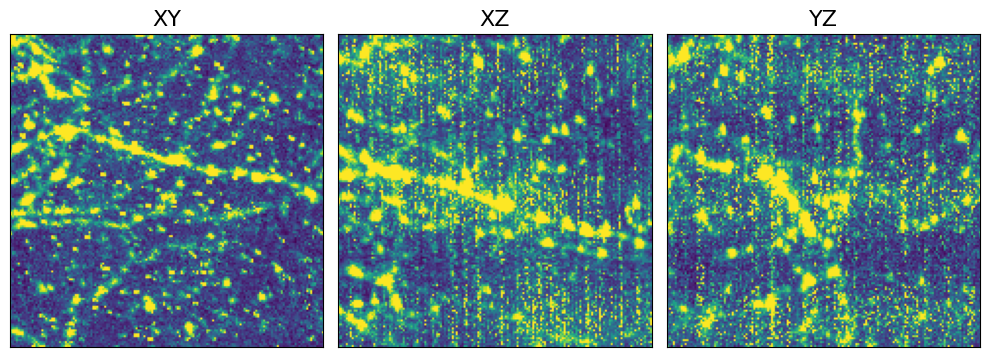

[component] Fragment skeleton (coloured by connected component):


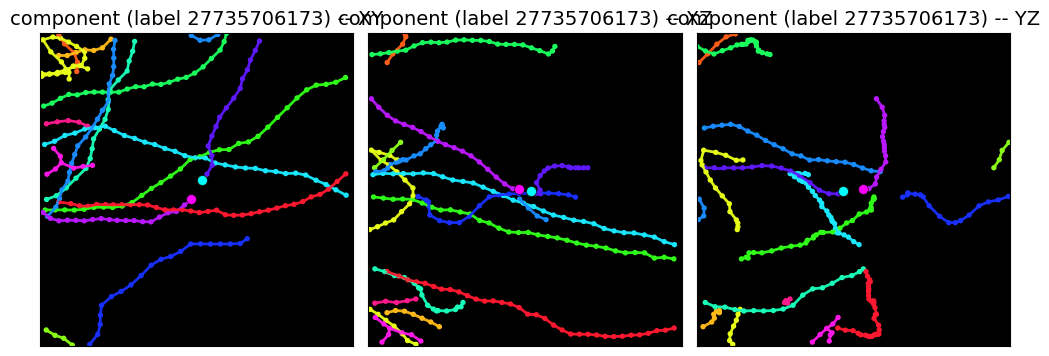


legend: yellow X = cut node (split location);  cyan = seed A;  magenta = seed B


In [57]:
def render(det, s):
    if s is None:
        print(f"\n=== {det}: nothing to render ==="); return
    center_voxel = img_util.to_voxels(tuple(s.cut_xyz), aniso)          # (z, y, x)
    offset = tuple(c - d // 2 for c, d in zip(center_voxel, PATCH_SHAPE))
    fr_nodes, fr_ncomp = fr_viz.nodes_in_patch(offset, PATCH_SHAPE, return_components=True)
    fr_edges, fr_ecomp = fr_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)

    _why = {"branch": "two neurites meet at a degree>=3 node (touch / crossing)",
            "bridge": "two neurites fused end-to-end at a degree-2 NECK with a sharp kink "
                      "(no branch node — branch scan misses it)",
            "component": "one label over >=2 DISCONNECTED components (no shared vertex — "
                         "walk-based detectors can't reach across)"}[det]
    print(f"\n=== [{det}] label {s.label}  deg {s.branch_degree}  "
          f"cables {s.cable_a_um:.1f}/{s.cable_b_um:.1f}um  angle {s.angle_deg:.0f}deg ===")
    print(f"    {_why}")
    print(f"    fragment nodes/edges in patch: {len(fr_nodes)}/{len(fr_edges)}")

    if WITH_IMAGE:
        try:
            img_patch = np.squeeze(bd.img.read(center_voxel, PATCH_SHAPE))
            print("Raw image (MIP):"); img_util.plot_mips(img_patch)
        except Exception as e:
            print(f"    [image read failed: {e}]")

    print(f"[{det}] Fragment skeleton (coloured by connected component):")
    # Keep the figure OPEN while we add markers: plot_skeleton_mips ends with
    # plt.show(), which under the inline backend displays + CLOSES the figure
    # BEFORE our scatter runs (so markers vanish inline; they only survived in the
    # PDF because §3 no-ops plt.show). Suppress it here, add markers, then show.
    _real_show = plt.show
    plt.show = lambda *a, **k: None
    try:
        img_util.plot_skeleton_mips({
            f"{det} (label {s.label})": {"nodes": fr_nodes, "node_components": fr_ncomp,
                                         "edges": fr_edges, "components": fr_ecomp, "color": "red"},
        }, PATCH_SHAPE, separate_rows=True)
    finally:
        plt.show = _real_show

    # Mark cut node (yellow X) + the two seeds (cyan / magenta) on each XY/XZ/YZ panel.
    from agentic_neuron_proofreader.data_modules.graph_classes import SkeletonGraph  # noqa
    plane_axes = [(1, 2), (0, 2), (0, 1)]      # (row a, col b) over local (z,y,x)
    def _loc(node):
        v = np.asarray(img_util.to_voxels(tuple(fr_viz.node_xyz[node]), aniso), float)
        return v - np.asarray(offset, float)
    pts = [("cut", s.cut_node, "yellow", "X"),
           ("seed_a", s.seed_a_node, "cyan", "o"),
           ("seed_b", s.seed_b_node, "magenta", "o")]
    for ax, (a, b) in zip(plt.gcf().axes, plane_axes):
        for _nm, node, col, mk in pts:
            try:
                loc = _loc(int(node))
                ax.scatter([loc[b]], [loc[a]], c=col, marker=mk, s=50,
                           edgecolors="black", linewidths=0.4, zorder=12)
            except Exception:
                pass

    plt.show()  # display the figure WITH the markers added above

for det in ("branch", "bridge", "component"):
    render(det, examples[det])
print("\nlegend: yellow X = cut node (split location);  cyan = seed A;  magenta = seed B")

## 2b. Ground-truth skeleton in each patch

Renders the GROUND-TRUTH skeleton (`bd.gt_graph`, coloured by GT neuron component) in the
same patch as each exemplar, with the cut node + seeds marked. A real merge error should show
**two DISTINCT GT components** passing through the patch — the cut sits between them. Self-
contained: reuses `bd`, `examples`, `PATCH_SHAPE`, `aniso` already in memory (no re-enumeration),
so it can be run on its own after §0–§2.


=== [branch] GT in patch: 146 nodes / 143 edges over 2 GT neuron component(s)  (label 26541564599) ===
    >=2 GT components => a genuine two-neuron site


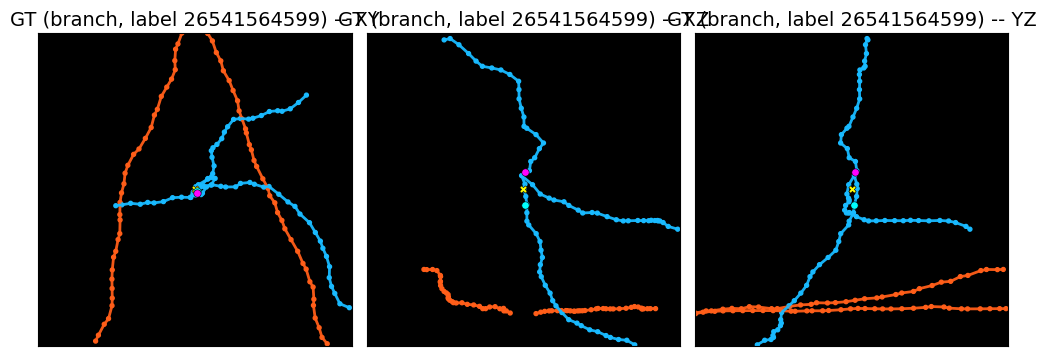


=== [bridge] GT in patch: 67 nodes / 65 edges over 2 GT neuron component(s)  (label 20215376686) ===
    >=2 GT components => a genuine two-neuron site


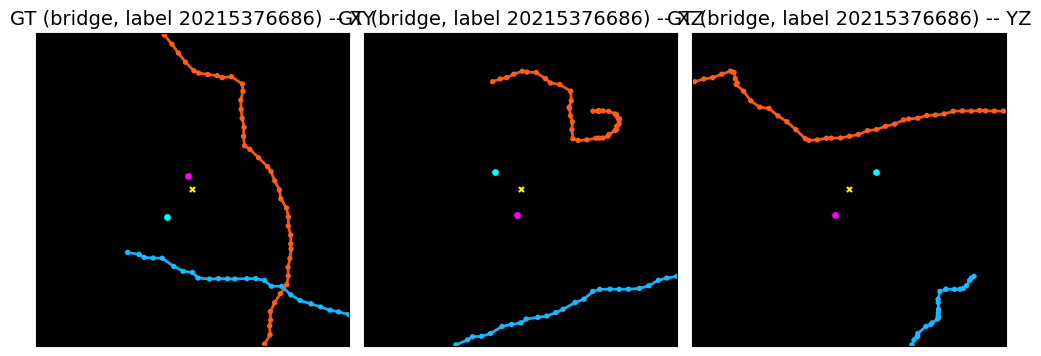


=== [component] GT in patch: 0 nodes / 0 edges over 0 GT neuron component(s)  (label 27735706173) ===
    (no GT skeleton in this patch — this region is untraced in the GT)

legend: lime = GT skeleton (by neuron);  yellow X = cut;  cyan/magenta = seeds


In [58]:
# GT skeleton in each exemplar's patch (coloured by GT neuron component). Standalone:
# pulls bd.gt_graph itself and reuses examples / PATCH_SHAPE / aniso from §0-§1.
gt_viz = bd.gt_graph

def render_gt(det, s):
    if s is None:
        print(f"\n=== {det}: nothing to render ==="); return
    center_voxel = img_util.to_voxels(tuple(s.cut_xyz), aniso)          # (z, y, x)
    offset = tuple(c - d // 2 for c, d in zip(center_voxel, PATCH_SHAPE))
    gt_nodes, gt_ncomp = gt_viz.nodes_in_patch(offset, PATCH_SHAPE, return_components=True)
    gt_edges, gt_ecomp = gt_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)
    n_gt_comp = len(set(gt_ncomp)) if len(gt_ncomp) else 0
    print(f"\n=== [{det}] GT in patch: {len(gt_nodes)} nodes / {len(gt_edges)} edges over "
          f"{n_gt_comp} GT neuron component(s)  (label {s.label}) ===")
    if len(gt_nodes) == 0:
        print("    (no GT skeleton in this patch — this region is untraced in the GT)")
        return
    print(f"    {'>=2 GT components => a genuine two-neuron site' if n_gt_comp >= 2 else 'only 1 GT component in patch (single neuron here, or GT sparse)'}")
    # Keep the figure OPEN while we add markers: plot_skeleton_mips ends with
    # plt.show(), which under the inline backend displays + CLOSES the figure
    # BEFORE our scatter runs (so markers vanish inline; they only survived in the
    # PDF because §3 no-ops plt.show). Suppress it here, add markers, then show.
    _real_show = plt.show
    plt.show = lambda *a, **k: None
    try:
        img_util.plot_skeleton_mips({
            f"GT ({det}, label {s.label})": {"nodes": gt_nodes, "node_components": gt_ncomp,
                                             "edges": gt_edges, "components": gt_ecomp,
                                             "color": "lime"},
        }, PATCH_SHAPE, separate_rows=True)
    finally:
        plt.show = _real_show

    # Mark the cut node (yellow X) + seeds (cyan / magenta) on each XY/XZ/YZ panel, so the
    # cut can be compared against where the two GT neurons actually separate.
    plane_axes = [(1, 2), (0, 2), (0, 1)]
    def _loc(node):
        v = np.asarray(img_util.to_voxels(tuple(fr_viz.node_xyz[node]), aniso), float)
        return v - np.asarray(offset, float)
    pts = [("cut", s.cut_node, "yellow", "X"),
           ("seed_a", s.seed_a_node, "cyan", "o"),
           ("seed_b", s.seed_b_node, "magenta", "o")]
    for ax, (a, b) in zip(plt.gcf().axes, plane_axes):
        for _nm, node, col, mk in pts:
            try:
                loc = _loc(int(node))
                ax.scatter([loc[b]], [loc[a]], c=col, marker=mk, s=28,
                           edgecolors="black", linewidths=0.4, zorder=12)
            except Exception:
                pass

    plt.show()  # display the figure WITH the markers added above

for det in ("branch", "bridge", "component"):
    render_gt(det, examples[det])
print("\nlegend: lime = GT skeleton (by neuron);  yellow X = cut;  cyan/magenta = seeds")

## 3. Save each example to a PDF (optional)

In [59]:
from matplotlib.backends.backend_pdf import PdfPages
OUT = PROJ / "proofreader_evolve" / f"mergesite_detector_examples_{BRAIN}"
OUT.mkdir(parents=True, exist_ok=True)
_real_show = plt.show; plt.show = lambda *a, **k: None
try:
    for det in ("branch", "bridge", "component"):
        s = examples[det]
        if s is None:
            continue
        plt.close("all")
        render(det, s)        # raw image MIP + fragment skeleton figures
        render_gt(det, s)     # GT skeleton figure -> into the SAME per-detector PDF
        figs = [plt.figure(n) for n in plt.get_fignums()]  # all figs from BOTH renders
        pdf_path = OUT / f"{det}_label{s.label}_cut{s.cut_node}.pdf"
        with PdfPages(pdf_path) as pdf:
            for f in figs:
                pdf.savefig(f, bbox_inches="tight")
        print(f"saved {det} ({len(figs)} figs incl. GT) -> {pdf_path}")
finally:
    plt.show = _real_show; plt.close("all")


=== [branch] label 26541564599  deg 3  cables 28.5/28.3um  angle 146deg ===
    two neurites meet at a degree>=3 node (touch / crossing)
    fragment nodes/edges in patch: 125/122
Raw image (MIP):
[branch] Fragment skeleton (coloured by connected component):

=== [branch] GT in patch: 146 nodes / 143 edges over 2 GT neuron component(s)  (label 26541564599) ===
    >=2 GT components => a genuine two-neuron site
saved branch (3 figs incl. GT) -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/mergesite_detector_examples_794495/branch_label26541564599_cut12334641.pdf

=== [bridge] label 20215376686  deg 2  cables 28.5/29.2um  angle 115deg ===
    two neurites fused end-to-end at a degree-2 NECK with a sharp kink (no branch node — branch scan misses it)
    fragment nodes/edges in patch: 101/97
Raw image (MIP):
[bridge] Fragment skeleton (coloured by connected component):

=== [bridge] GT in patch: 67 nodes / 65 edges over 2 GT n

## 4. Why three detectors (recap)

| detector | fusion shape | cut location | why the others miss it |
|---|---|---|---|
| **branch** | two arms meet at a vertex | degree>=3 node | — |
| **bridge** | two neurites end-to-end, no branch | degree-2 sharp neck | seam is degree-2; branch scans degree>=3 only |
| **component** | one label over disconnected pieces | nearest-pair midpoint | no edge between pieces; walk-based detectors can't cross |

These are complementary COVERAGE, not redundancy: each corresponds to a distinct physical way
two neurons get glued. Drop one and that class of merge error is never enumerated as a
MergeSite — so no policy (and no two-phase split-first repair) can ever reach it. That missed
class is exactly the enumeration ceiling `site_recall_ceiling.ipynb` measures.